# Realistic-noise campaign — Noisy_Ladder / Noisy_Density (fixed vs formula ε)

**Purpose.** First full exploration of the realistic-noise campaign: all four noise
channels on simultaneously (σ_scatt = 1e-4, σ_res = 10 µm, drop = 1%), fixed 2 mrad
window vs formula ε = 3.178 mrad, size ladder T ∈ {10…1000} (φ_max = 0.2) and density
scan φ_max ∈ {0.01, 0.02, 0.05, 0.1, 0.2}. Step kernel, γ = 3, δ = 1.

**Provenance.** qtrk_store view (this notebook is view-driven; `max_abs_x` column =
per-solve validity gate ≤ 50). Campaign: 800 events / 1,880 solves + qsvt mirror rows;
first-look script `noisy_first_look.py` (commit `8f385a5c`), write-up
"Realistic-noise size & density study". Re-executed 2026-07-04 on the rebuilt view.

In [1]:
import os, sys, time
from pathlib import Path
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ.setdefault("QTRK_STORE", "/data/bfys/gscriven/qtrk_store")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qtrk_pipeline as qp

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_CLS, C_Q, C_QSVT = "#33322e", "#e34948", "#2a78d6"
FAR_FLOOR = 5e-5   # far=0 rendered as open marker at the floor on log axes

MPATH = Path(os.environ["QTRK_STORE"]) / "manifest" / "metrics.csv"
M = pd.read_csv(MPATH)
print(f"metrics view: {len(M):,} rows, mtime {time.ctime(MPATH.stat().st_mtime)}")
print(M.solver.value_counts().to_string())

def far_plot(ax, x, y, **kw):
    """Plot false rate on a log axis with far=0 as open markers at the floor."""
    y = np.asarray(y, float)
    zero = y <= 0
    ax.plot(x, np.maximum(y, FAR_FLOOR), **kw)
    if zero.any():
        kw2 = {k: v for k, v in kw.items() if k in ("color", "marker")}
        ax.plot(np.asarray(x)[zero], np.full(zero.sum(), FAR_FLOOR),
                ls="none", mfc="white", **kw2)


metrics view: 23,087 rows, mtime Sat Jul  4 21:21:43 2026
solver
classical    14683
quantum       6005
qsvt          2399


In [2]:
# exact-token membership (a scalar study startswith drops shared cells) + the
# standard validity gate (classical partner max|x| <= 50, quantum/qsvt via partner)
N = qp.add_validity(pd.concat([qp.load_metrics(study="Noisy_Ladder"),
                               qp.load_metrics(study="Noisy_Density")]).drop_duplicates("sol_key"))
N["window"] = np.where(N.eps_provenance == "set", "fixed 2 mrad", "formula 3.178 mrad")
print(N.groupby(["study", "window", "solver"]).size().unstack(fill_value=0).to_string())
print(f"valid frac: {N.valid.mean():.3f}")
C_FIX, C_FORM = "#eb6834", "#2a78d6"

solver                            classical  qsvt  quantum
study         window                                      
Noisy_Density fixed 2 mrad              640   112      112
              formula 3.178 mrad        640   112      112
Noisy_Ladder  fixed 2 mrad              160    28       28
              formula 3.178 mrad        160    28       28
valid frac: 0.745


## Size ladder (φ_max = 0.2): efficiency & false rate vs T, both windows, three solvers

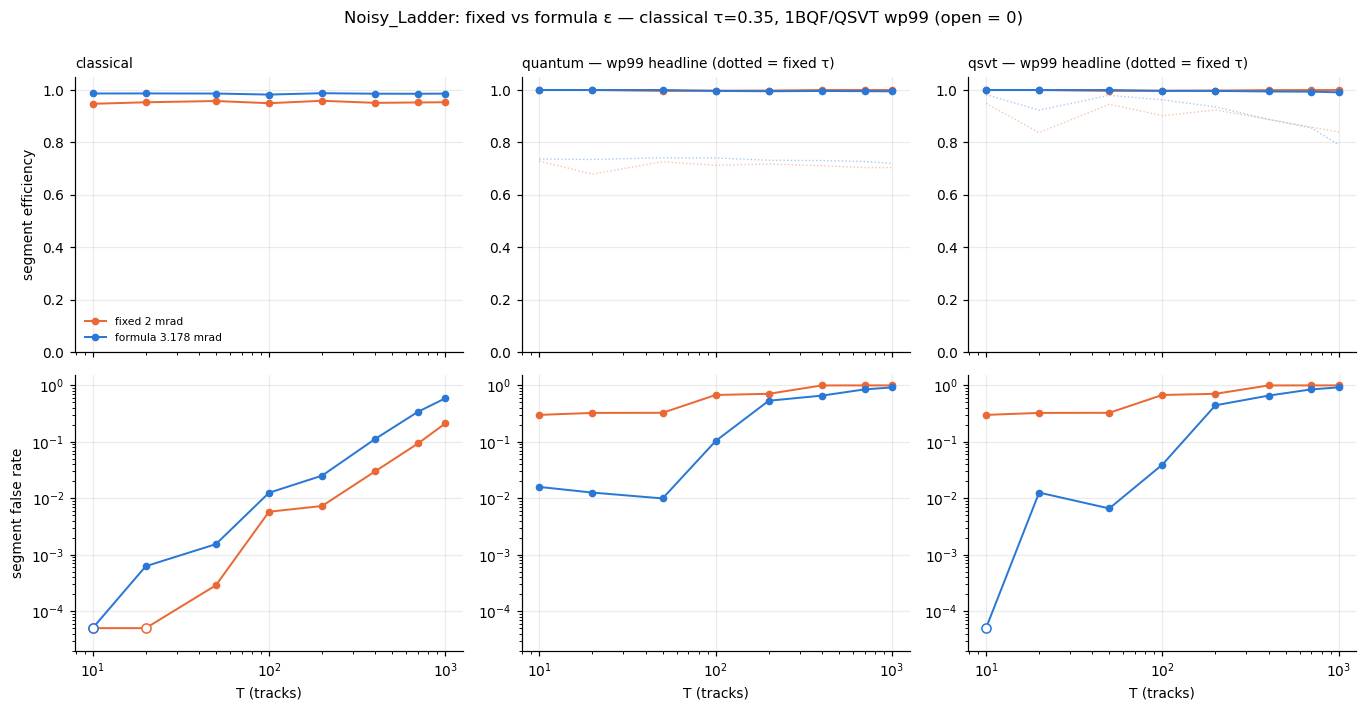

                                    segment_efficiency  segment_false_rate  segment_efficiency_wp  segment_false_rate_wp
window             solver    n_trk                                                                                      
fixed 2 mrad       classical 50               0.958055            0.000287               0.997987               0.543489
                             200              0.958917            0.007296               0.999685               0.952049
                             1000             0.953373            0.211689               1.000000               0.999000
                   qsvt      50               0.945853            0.000000               0.996633               0.326667
                             200              0.923900            0.000000               0.997898               0.708655
                             1000             0.840234            0.010180               0.999949               0.999000
                   quantum   50 

In [3]:
# Operating points (project convention, wp99 log 2026-06-14): classical = fixed
# gamma-aware tau (0.35 at gamma=3); 1BQF and QSVT HEADLINE = wp99 (efficiency-first,
# tau at the 1% true-amplitude quantile -> ~99-100% eff, false rate honestly paid).
# The fixed-tau 1BQF curve is the artefactual ~70-75% plateau -> kept only as a
# faded dotted diagnostic.
L = N[(N.phi_max == 0.2) & N.valid]          # ladder (phi=0.2; zero exclusions here)
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.4), sharex=True)
for j, (solver, ec, fc) in enumerate([
        ("classical", "segment_efficiency", "segment_false_rate"),
        ("quantum", "segment_efficiency_wp", "segment_false_rate_wp"),
        ("qsvt", "segment_efficiency_wp", "segment_false_rate_wp")]):
    for window, c in [("fixed 2 mrad", C_FIX), ("formula 3.178 mrad", C_FORM)]:
        g = L[(L.solver == solver) & (L.window == window)].groupby("n_trk")
        if not len(g):
            continue
        axes[0, j].plot(g[ec].mean().index, g[ec].mean().values,
                        marker="o", ms=4, lw=1.3, color=c, label=window)
        far_plot(axes[1, j], g[fc].mean().index, g[fc].mean().values,
                 marker="o", ms=4, lw=1.3, color=c, label=window)
        if solver != "classical":   # faded fixed-tau diagnostic (the ~70-75% artefact)
            axes[0, j].plot(g.segment_efficiency.mean().index,
                            g.segment_efficiency.mean().values,
                            color=c, lw=0.9, ls=":", alpha=0.4)
    ttl = solver if solver == "classical" else f"{solver} — wp99 headline (dotted = fixed τ)"
    axes[0, j].set_title(ttl, loc="left", fontsize=9); axes[0, j].set_ylim(0, 1.05)
    axes[1, j].set_yscale("log"); axes[1, j].set_xscale("log"); axes[1, j].set_ylim(2e-5, 1.5)
    axes[1, j].set_xlabel("T (tracks)")
axes[0, 0].set_ylabel("segment efficiency"); axes[1, 0].set_ylabel("segment false rate")
axes[0, 0].legend(fontsize=7)
fig.suptitle("Noisy_Ladder: fixed vs formula ε — classical τ=0.35, 1BQF/QSVT wp99 (open = 0)", y=1.0)
fig.tight_layout(); fig.savefig("figures/noisy_nb_ladder.png", bbox_inches="tight"); plt.show()
print(L[L.n_trk.isin([50, 200, 1000])].groupby(["window", "solver", "n_trk"])[
    ["segment_efficiency", "segment_false_rate", "segment_efficiency_wp",
     "segment_false_rate_wp"]].mean().to_string())

## Density scan: false rate vs T per cone, and the explosion frontier

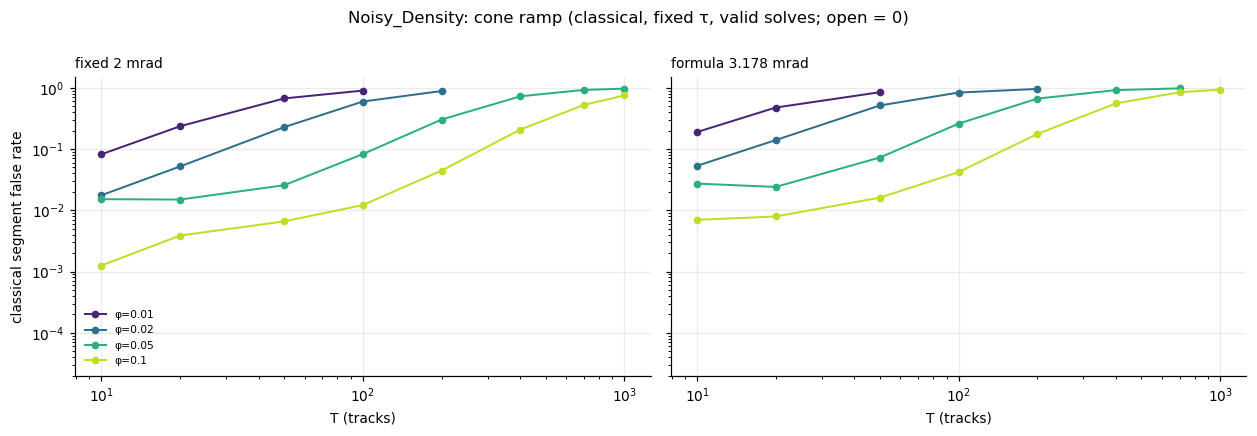

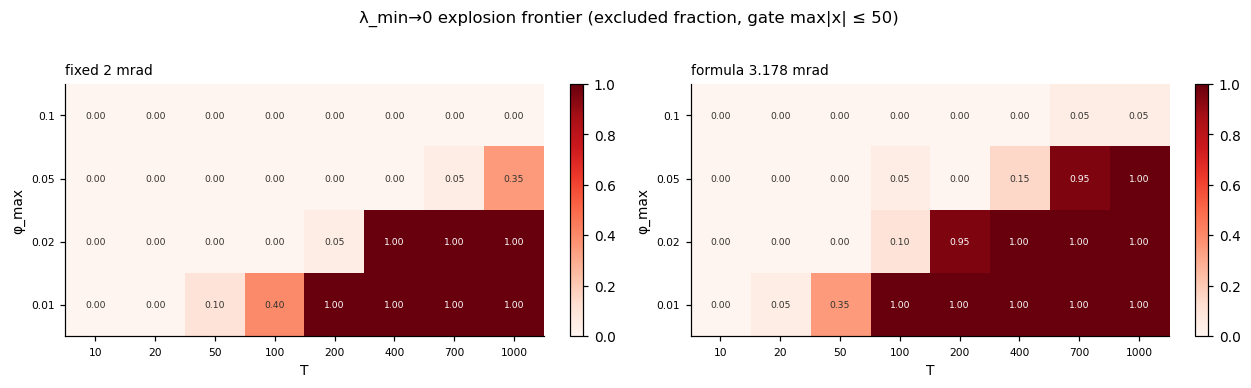

In [4]:
D = N[N.phi_max < 0.2]                       # density scan (tight cones)
phis = sorted(D.phi_max.unique())
ramp = plt.cm.viridis(np.linspace(0.1, 0.9, len(phis)))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for ax, window in zip(axes, ["fixed 2 mrad", "formula 3.178 mrad"]):
    for phi, c in zip(phis, ramp):
        # far curves over VALID solves only — the exploded cells belong to the
        # frontier map below, not to the false-rate physics
        g = D[(D.solver == "classical") & (D.window == window)
              & (D.phi_max == phi) & D.valid].groupby("n_trk")
        if not len(g):
            continue
        far_plot(ax, g.segment_false_rate.mean().index, g.segment_false_rate.mean().values,
                 marker="o", ms=4, lw=1.3, color=c, label=f"φ={phi:g}")
    ax.set_yscale("log"); ax.set_xscale("log"); ax.set_ylim(2e-5, 1.5)
    ax.set_title(window, loc="left", fontsize=9); ax.set_xlabel("T (tracks)")
axes[0].set_ylabel("classical segment false rate"); axes[0].legend(fontsize=7)
fig.suptitle("Noisy_Density: cone ramp (classical, fixed τ, valid solves; open = 0)", y=1.0)
fig.tight_layout(); fig.savefig("figures/noisy_nb_density.png", bbox_inches="tight"); plt.show()

# explosion frontier straight from the view's max_abs_x column
exc = D[D.solver == "classical"].assign(exc=lambda d: d.max_abs_x > 50)
piv = {w: exc[exc.window == w].pivot_table(index="phi_max", columns="n_trk",
                                           values="exc", aggfunc="mean")
       for w in ["fixed 2 mrad", "formula 3.178 mrad"]}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for ax, (w, pv) in zip(axes, piv.items()):
    im = ax.imshow(pv.values, aspect="auto", cmap="Reds", vmin=0, vmax=1, origin="lower")
    ax.set_xticks(range(len(pv.columns)), [str(t) for t in pv.columns], fontsize=7)
    ax.set_yticks(range(len(pv.index)), [f"{p:g}" for p in pv.index], fontsize=7)
    for (i, j), v in np.ndenumerate(pv.values):
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if v > 0.5 else "#33322e")
    ax.set_title(w, loc="left", fontsize=9); ax.set_xlabel("T"); ax.set_ylabel("φ_max")
    ax.grid(False); fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("λ_min→0 explosion frontier (excluded fraction, gate max|x| ≤ 50)", y=1.02)
fig.tight_layout(); fig.savefig("figures/noisy_nb_explosion_map.png", bbox_inches="tight"); plt.show()

## Activation spectra at T = 200 (ladder, both windows) — streamed vectors

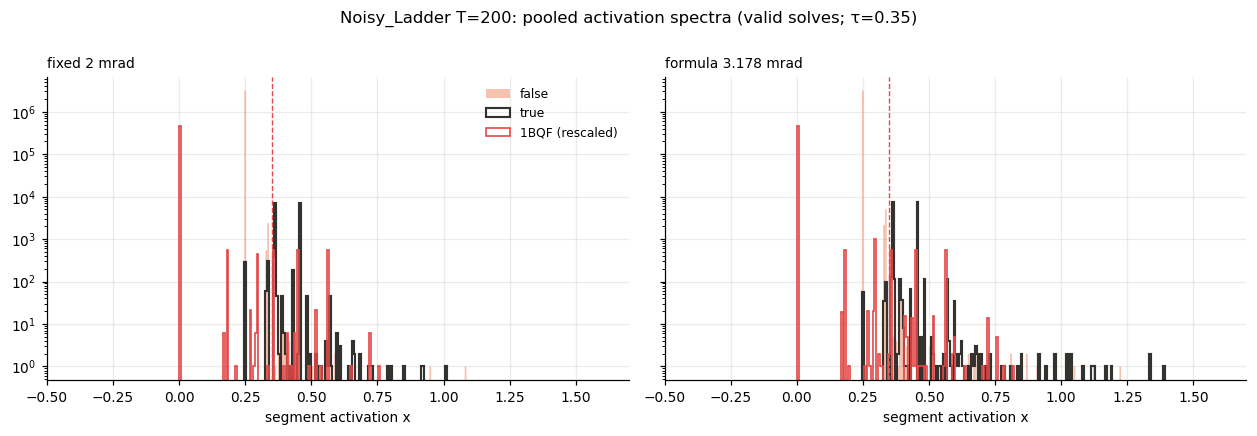

In [5]:
from qtrk_pipeline.metrics import rescale_to_signal
TAU = 0.35
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for ax, window in zip(axes, ["fixed 2 mrad", "formula 3.178 mrad"]):
    sel = N[(N.study == "Noisy_Ladder") & (N.n_trk == 200) & (N.window == window)]
    pt, pf, pq = [], [], []
    solc = {}
    for r in sel[sel.solver == "classical"].itertuples(index=False):
        if r.max_abs_x > 50:
            continue
        s = qp.load_solution(r.sol_key)["sol"]
        t = qp.truth_from_event(qp.load_event(qp.event_path(r.event_key))).astype(bool)
        pt.append(s[t]); pf.append(s[~t]); solc[(r.event_key, r.ham_key)] = s
    for r in sel[sel.solver == "quantum"].itertuples(index=False):
        key = (r.event_key, r.ham_key)
        if key in solc:
            pq.append(rescale_to_signal(qp.load_solution(r.sol_key)["sol"], solc[key], TAU))
    bins = np.linspace(-0.4, 1.6, 301)
    ax.hist(np.clip(np.concatenate(pf), bins[0], bins[-1]), bins=bins, histtype="stepfilled",
            alpha=0.4, color="#eb6834", label="false")
    ax.hist(np.clip(np.concatenate(pt), bins[0], bins[-1]), bins=bins, histtype="step",
            lw=1.4, color=C_CLS, label="true")
    if pq:
        ax.hist(np.clip(np.concatenate(pq), bins[0], bins[-1]), bins=bins, histtype="step",
                lw=1.1, color=C_Q, label="1BQF (rescaled)")
    ax.axvline(TAU, color=C_Q, lw=0.9, ls="--")
    ax.set_yscale("log"); ax.set_title(window, loc="left", fontsize=9)
    ax.set_xlabel("segment activation x")
axes[0].legend(fontsize=8)
fig.suptitle("Noisy_Ladder T=200: pooled activation spectra (valid solves; \u03c4=0.35)", y=1.0)
fig.tight_layout(); fig.savefig("figures/noisy_nb_spectra_T200.png", bbox_inches="tight"); plt.show()

## Findings (1BQF/QSVT at the wp99 headline; classical at τ=0.35)

- **Zero explosions at φ_max = 0.2** for either window at realistic noise — the ladder is
  in the healthy regime to T = 1000; the explosion frontier is a **density × window**
  phenomenon (tight cones + wide formula window first).
- **Window choice is solver-dependent, and at the proper operating points the split is
  dramatic.** Classically the fixed 2 mrad window wins at high T (~21% vs ~59% far at
  T = 1000, τ=0.35). For the **1BQF at wp99** it is the *formula* window that wins:
  far **1.0% vs 33%** at T = 50 (both at ~100% efficiency), 53% vs 71% at T = 200;
  by T = 1000 both windows saturate (0.92 vs 0.999) — realistic noise makes the
  99%-efficiency working point expensive at high multiplicity.
- The fixed-τ 1BQF curves (dotted, ~0.70–0.73 "efficiency") are the cut artefact —
  the 0.35 cut chops the halved outer-true band. At wp99 the 1BQF recovers
  99.5–100% of true segments on this ladder at every T; the quoted false rate is
  the honest price, which the QSVT comb's line-filtering is designed to reduce.